# Question 2

In [3]:
import scimap
import anndata as ad
import matplotlib.pyplot as plt
from IPython.display import Image
import numpy as np
import random
import math
import pandas as pd

Running SCIMAP  2.3.5


## Part A

### i.

In [6]:
a_d = ad.read_h5ad("S2026HW2\sc_pca.h5ad")
a_d

AnnData object with n_obs × n_vars = 34162 × 0
    obs: 'merged_annotation'
    obsm: 'X_pca'

In [7]:
X_pca = a_d.obsm["X_pca"]
X_pca.shape[1]

30

In [8]:
a_d.obs.copy()

,merged_annotation
index,
N51.LPA.TCATTTGGTCAGAAGC,Plasma
N18.LPB.GGTAGTACACAGTC,Plasma
N10.LPB.GTACGAACCTATTC,Plasma
N11.LPB.TCCGAAGAAGATGA,Plasma
N51.LPA.GTTACAGCACAGAGGT,Plasma
...,...
N46.LPB.TGCACCTCAGGATTGG,Immature Goblet
N46.LPB.TGGCGCAAGCTACCGC,Immature Enterocytes 1
N46.LPB.TGTGGTAGTCTGATTG,Immature Goblet


In [9]:
idx = []
for i in range(30):
    idx.append(f"PC{i+1}")
df = pd.DataFrame(index=idx)
df

""
PC1
PC2
PC3
PC4
PC5
PC6
PC7
PC8
PC9
PC10


In [10]:
adata = ad.AnnData(X=X_pca,obs=a_d.obs.copy(),var=df)
print(adata.obs, adata.var)

                               merged_annotation
index                                           
N51.LPA.TCATTTGGTCAGAAGC                  Plasma
N18.LPB.GGTAGTACACAGTC                    Plasma
N10.LPB.GTACGAACCTATTC                    Plasma
N11.LPB.TCCGAAGAAGATGA                    Plasma
N51.LPA.GTTACAGCACAGAGGT                  Plasma
...                                          ...
N46.LPB.TGCACCTCAGGATTGG         Immature Goblet
N46.LPB.TGGCGCAAGCTACCGC  Immature Enterocytes 1
N46.LPB.TGTGGTAGTCTGATTG         Immature Goblet
N46.LPB.TTGCGTCTCACCTCGT             Enterocytes
N46.LPB.TTTGGTTTCAATCACG         Immature Goblet

[34162 rows x 1 columns] Empty DataFrame
Columns: []
Index: [PC1, PC2, PC3, PC4, PC5, PC6, PC7, PC8, PC9, PC10, PC11, PC12, PC13, PC14, PC15, PC16, PC17, PC18, PC19, PC20, PC21, PC22, PC23, PC24, PC25, PC26, PC27, PC28, PC29, PC30]


In [11]:
X = adata.X
sses = []

for k in range(1, 15):
    scimap.tl.cluster(adata,method="kmeans",k=k,label=f"kmeans_{k}",use_raw = False,random_state=42)
    labels = adata.obs[f"kmeans_{k}"].astype(int).values
    centroids = np.array([X[labels == j].mean(axis=0)for j in range(k)])
    sse_k = sum(np.linalg.norm(X[labels == j] - centroids[j], axis=1).sum()for j in range(k))
    sses.append(sse_k)
sses

Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering
Kmeans clustering


[534636.375,
 448495.453125,
 401646.6640625,
 368894.484375,
 345690.97265625,
 328151.68359375,
 311812.453125,
 298877.962890625,
 289080.962890625,
 281630.275390625,
 275282.1025390625,
 271200.8388671875,
 268167.6318359375,
 264830.0859375]

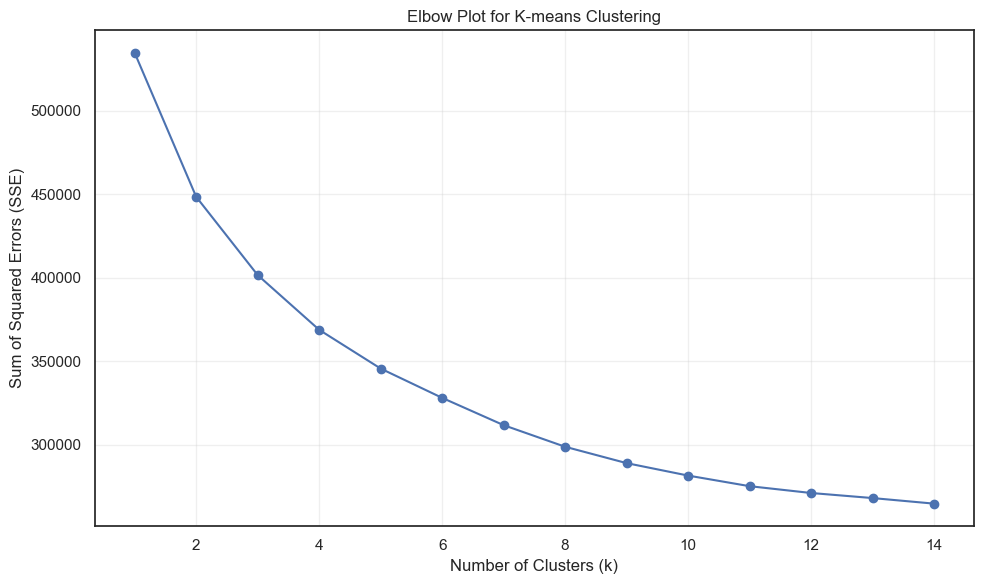

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 15), sses, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Plot for K-means Clustering')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Bases on the produced elbow plot, the elbow point appears to be between 10. This means that 5 is the most optimal number of clusters (the last point befroe the rate of decrease in SSE becomes approximately linear). It does not work too well on sc data however due to noise in the data espetially considering the diversity of DE genes. Additionally, like the plot above, it is difficult to discern where that elbow point actually as anoother scientist could argue the point is at 11 or 8.

### ii.

In [31]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
scimap.tl.cluster(adata,method='kmeans',k=10,label='kmeans_10',use_raw = False,random_state=42)

# Calculate SSE
X = adata.X
labels = adata.obs['kmeans_10'].astype(int).values
centroids = np.array([X[labels == j].mean(axis=0) for j in range(10)])
sse = sum(np.linalg.norm(X[labels == j] - centroids[j], axis=1).sum() for j in range(10))

print(f"Final SSE with stable random_state=42: {sse:.2f}")


Kmeans clustering
Final SSE with stable random_state=42: 281630.28


## iii.

In [22]:
def adjusted_rand_index(labels_true, labels_pred):
    contingency = np.zeros((len(np.unique(true_labels)), len(np.unique(labels))), dtype=int)
    for i in range(len(true_labels)):
        contingency[true_labels[i], labels[i]] += 1
    a = np.sum([math.comb(n, 2) for n in np.sum(contingency, axis=1)])
    b = np.sum([math.comb(n, 2) for n in np.sum(contingency, axis=0)])
    ab = np.sum([math.comb(n, 2) for n in contingency.flatten() if n > 1])
    total_pairs = math.comb(len(true_labels), 2)
    ri = (ab + (total_pairs - a - b + ab)) / total_pairs
    expected_ri = (a * b) / total_pairs
    max_ri = (a + b) / 2
    ari = (ri - expected_ri) / (max_ri - expected_ri)
    return ari

In [24]:
true_labels = adata.obs['merged_annotation'].astype('category').cat.codes.values

ari = adjusted_rand_index(true_labels, labels)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")


Adjusted Rand Index (ARI): -0.0000


C:\Users\Trish\AppData\Local\Temp\ipykernel_27356\3703409219.py:10: RuntimeWarning:

overflow encountered in scalar multiply



The ARI value of 0 can mean that the clusters are random and independent.

## B

### i.

In [29]:
scimap.tl.cluster(adata,method='leiden',nearest_neighbors=20,resolution=0.1,label='leiden_0.1',random_state=42,use_raw=False, phenograph_clustering_metric = 'Euclidean')

Leiden clustering


C:\Users\Trish\anaconda3\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:384: ImplicitModificationWarning:

Setting element `.obsm['X_pca']` of view, initializing view as actual.

C:\Users\Trish\anaconda3\Lib\site-packages\scimap\tools\cluster.py:174: FutureWarning:

In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.



AnnData object with n_obs × n_vars = 34162 × 30
    obs: 'merged_annotation', 'kmeans_1', 'kmeans_2', 'kmeans_3', 'kmeans_4', 'kmeans_5', 'kmeans_6', 'kmeans_7', 'kmeans_8', 'kmeans_9', 'kmeans_10', 'kmeans_11', 'kmeans_12', 'kmeans_13', 'kmeans_14', 'leiden_0.1'

Distance metric is Euclidean (it's the default).

## ii.

In [33]:
# Count clusters obtained
leiden_labels = adata.obs['leiden_0.1'].astype(int)
n_leiden_clusters = leiden_labels.nunique()
print("Number of obtained leiden cluster:", n_leiden_clusters)
ll = pd.DataFrame(leiden_labels).value_counts().sort_index()
ll

Number of obtained leiden cluster: 9


leiden_0.1
0             7233
1             6133
2             4936
3             4482
4             3562
5             2843
6             2638
7             1667
8              668
Name: count, dtype: int64

### iii.

In [35]:
# Extract labels
true_labels = adata.obs['merged_annotation'].astype('category').cat.codes.values
ari_leiden = adjusted_rand_index(true_labels, leiden_labels)
print(f"ARI (Leiden res=0.1 vs merged_annotation): {ari_leiden:.4f}")


ARI (Leiden res=0.1 vs merged_annotation): -0.0000


C:\Users\Trish\AppData\Local\Temp\ipykernel_27356\3703409219.py:10: RuntimeWarning:

overflow encountered in scalar multiply



The ARI value of 0 can mean that the clusters are random and independent.

## C.

### i.

In [40]:
# Compute UMAP first (scimap)
scimap.tl.umap(adata)
# Run K-means k=4
scimap.tl.cluster(adata, method='kmeans', k=4, label='kmeans_4_umap', random_state=42, use_raw=False)

C:\Users\Trish\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Kmeans clustering


AnnData object with n_obs × n_vars = 34162 × 30
    obs: 'merged_annotation', 'kmeans_1', 'kmeans_2', 'kmeans_3', 'kmeans_4', 'kmeans_5', 'kmeans_6', 'kmeans_7', 'kmeans_8', 'kmeans_9', 'kmeans_10', 'kmeans_11', 'kmeans_12', 'kmeans_13', 'kmeans_14', 'leiden_0.1', 'kmeans_4_umap'
    obsm: 'umap'

### ii.

In [42]:
scimap.tl.cluster(adata, method='leiden', nearest_neighbors=20, resolution=0.01,label='leiden_0.01', random_state=42, use_raw=False)

Leiden clustering


C:\Users\Trish\anaconda3\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:384: ImplicitModificationWarning:

Setting element `.obsm['X_pca']` of view, initializing view as actual.



AnnData object with n_obs × n_vars = 34162 × 30
    obs: 'merged_annotation', 'kmeans_1', 'kmeans_2', 'kmeans_3', 'kmeans_4', 'kmeans_5', 'kmeans_6', 'kmeans_7', 'kmeans_8', 'kmeans_9', 'kmeans_10', 'kmeans_11', 'kmeans_12', 'kmeans_13', 'kmeans_14', 'leiden_0.1', 'kmeans_4_umap', 'leiden_0.01'
    obsm: 'umap'

### UMAP and Leiden plots vs ground truth UMAP

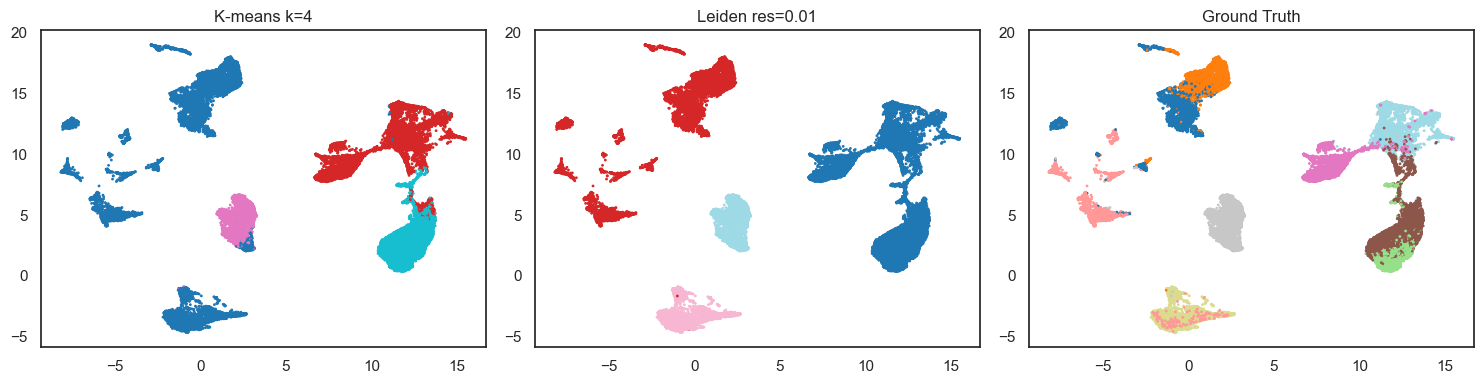

In [175]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Kmeans = 4 Umap
k4 = adata.obs['kmeans_4'].astype(int).values
axes[0].scatter(adata.obsm['umap'][:,0], adata.obsm['umap'][:,1], c=k4, cmap='tab10', s=1)
axes[0].set_title('K-means k=4')

# Leiden res=0.01 UMAP  
leiden01 = adata.obs['leiden_0.01'].astype(int).values
axes[1].scatter(adata.obsm['umap'][:,0], adata.obsm['umap'][:,1], c=leiden01, cmap='tab20', s=1)
axes[1].set_title('Leiden res=0.01')

# Ground truth UMAP
truth = adata.obs['merged_annotation'].astype('category').cat.codes.values
axes[2].scatter(adata.obsm['umap'][:,0], adata.obsm['umap'][:,1], c=truth, cmap='tab20', s=1)
axes[2].set_title('Ground Truth')

plt.tight_layout()
plt.show()

The potential disadvantage of K-means–based clustering methods in single-cell RNA-seq analysis is that cells can be forced into very specific clusters and underlying factors like DE GENES or specialized functions are ignored. When we look at the KMeans and Leiden plots side by side, we can see that in the Kmeans, there are some merging of clusters, but many cells are misclassified due to their approximate distance to the centroids, as compared to the Leiden plot. Thus, more cells are more likely misclassified as another cell type; their innate function are basically ignored due to proximity.